# Differentiable raster-to-vector training notebook

This notebook creates a synthetic vectorisation experiment for **64×64 raster images**. It generates drawings with **1 to 5 vector items**, where each item can be a straight line or a quadratic Bézier curve. Items may appear in any order, intersect, and extend beyond the image boundary.

The model receives the raster image plus a Sobel edge channel, predicts vector primitives, differentiably rasterises those predictions, compares the predicted raster to the input raster, and backpropagates from the raster-level reconstruction error.

The model is not trained to reproduce the original vector parameters exactly. It is trained to produce a vector image whose **rasterised output is visually close** to the target, even if it uses more vector primitives than the original.

## 0. Imports and setup

In [1]:
# Uncomment if needed:
# %pip install torch torchvision matplotlib numpy tqdm

import math
import json
import random
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Important on CPU: PyTorch can be much slower with too many threads for this renderer.
torch.set_num_threads(min(4, os.cpu_count() or 1))

print("PyTorch:", torch.__version__)
print("PyTorch CPU threads:", torch.get_num_threads())

C:\Users\elmak\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.12.0+cpu
PyTorch CPU threads: 4


## 1. Configuration

In [2]:
IMG_SIZE = 64
MAX_TRUE_ITEMS = 5

# IMPORTANT SPEED SETTINGS
# The differentiable rasteriser is expensive because it renders every predicted slot as a line and a curve.
# Start small, confirm it trains, then increase MAX_PRED_ITEMS / CURVE_SEGMENTS later.
MAX_PRED_ITEMS = 8        # use 8 for CPU/debug; try 16/24 later on GPU
OVERHANG = 0.40           # normalised coordinate overhang beyond the visible image
CURVE_SEGMENTS = 4        # use 4 for CPU/debug; try 8-12 later on GPU

# Keep these small for the first successful run.
# Increase after the cell below prints epoch results.
N_TRAIN = 256
N_VAL = 64
BATCH_SIZE = 8            # use 4-8 on CPU; 16-32 on GPU
EPOCHS = 3
LEARNING_RATE = 2e-4

# Requested behaviour: closer raster matches get a higher sample weight.
USE_MATCH_WEIGHTING = True
MATCH_WEIGHT_STRENGTH = 1.5

# Keep sparsity low because extra vectors are allowed.
SPARSITY_WEIGHT = 0.002
EDGE_LOSS_WEIGHT = 0.25

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Tip: if this says cpu, keep BATCH_SIZE <= 8, MAX_PRED_ITEMS <= 8, and CURVE_SEGMENTS <= 4 for the first run.")


Using device: cpu
Tip: if this says cpu, keep BATCH_SIZE <= 8, MAX_PRED_ITEMS <= 8, and CURVE_SEGMENTS <= 4 for the first run.


## 2. Weighted angle sampler

Line orientations are sampled in **1-degree increments** from 0 to 179 degrees. The distribution is uneven:

- 90-degree multiples get the highest weight;
- then 45-degree multiples;
- then 60, 30, 20, and 10;
- all remaining integer degrees are still possible.

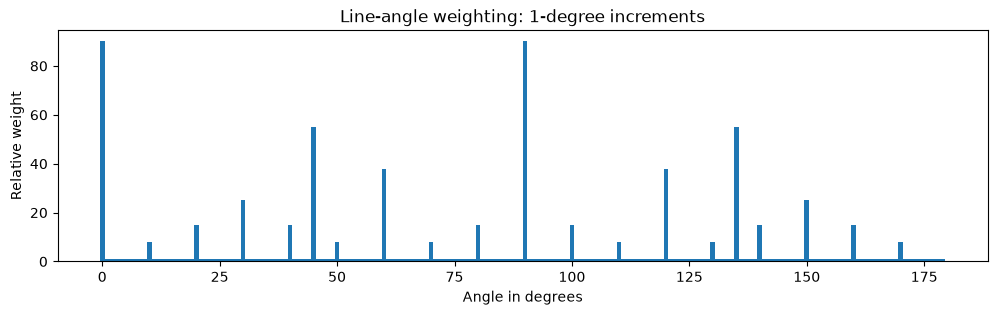

In [3]:
def build_angle_distribution():
    angles = np.arange(180, dtype=np.int64)
    weights = np.ones_like(angles, dtype=np.float64)

    for i, angle in enumerate(angles):
        if angle % 90 == 0:
            weights[i] = 90.0
        elif angle % 45 == 0:
            weights[i] = 55.0
        elif angle % 60 == 0:
            weights[i] = 38.0
        elif angle % 30 == 0:
            weights[i] = 25.0
        elif angle % 20 == 0:
            weights[i] = 15.0
        elif angle % 10 == 0:
            weights[i] = 8.0
        else:
            weights[i] = 1.0

    probabilities = weights / weights.sum()
    return angles, probabilities, weights

ANGLES, ANGLE_PROBS, ANGLE_WEIGHTS = build_angle_distribution()

def sample_weighted_angle_deg():
    return int(np.random.choice(ANGLES, p=ANGLE_PROBS))

plt.figure(figsize=(12, 3))
plt.bar(ANGLES, ANGLE_WEIGHTS, width=1.0)
plt.title("Line-angle weighting: 1-degree increments")
plt.xlabel("Angle in degrees")
plt.ylabel("Relative weight")
plt.show()

## 3. Synthetic vector generator

Primitive format:

```text
[exists, type, x0, y0, x1, y1, x2, y2, width]
```

`type` is `0` for a line and `1` for a quadratic Bézier curve. Coordinates use a normalised system where the visible image is from `0` to `1`. Values outside that range are allowed, so vectors can extend beyond the 64×64 grid.

In [4]:
def random_line_primitive():
    angle_deg = sample_weighted_angle_deg()
    theta = math.radians(angle_deg)
    direction = np.array([math.cos(theta), math.sin(theta)], dtype=np.float32)

    centre = np.random.uniform(-OVERHANG, 1.0 + OVERHANG, size=2).astype(np.float32)
    length = np.random.uniform(0.25, 1.85)

    p0 = centre - 0.5 * length * direction
    p2 = centre + 0.5 * length * direction
    p1 = 0.5 * (p0 + p2)
    width = np.random.uniform(1.0, 2.6) / IMG_SIZE

    return np.array([1.0, 0.0, p0[0], p0[1], p1[0], p1[1], p2[0], p2[1], width], dtype=np.float32)


def random_curve_primitive():
    # The chord direction also uses the weighted angle distribution.
    angle_deg = sample_weighted_angle_deg()
    theta = math.radians(angle_deg)
    direction = np.array([math.cos(theta), math.sin(theta)], dtype=np.float32)
    perpendicular = np.array([-direction[1], direction[0]], dtype=np.float32)

    centre = np.random.uniform(-OVERHANG, 1.0 + OVERHANG, size=2).astype(np.float32)
    chord_length = np.random.uniform(0.20, 1.65)

    p0 = centre - 0.5 * chord_length * direction
    p2 = centre + 0.5 * chord_length * direction
    curve_strength = np.random.uniform(-0.75, 0.75) * chord_length
    jitter = np.random.normal(0.0, 0.08, size=2).astype(np.float32)
    p1 = 0.5 * (p0 + p2) + curve_strength * perpendicular + jitter

    width = np.random.uniform(1.0, 2.6) / IMG_SIZE
    return np.array([1.0, 1.0, p0[0], p0[1], p1[0], p1[1], p2[0], p2[1], width], dtype=np.float32)


def generate_vector_sample(max_items=MAX_TRUE_ITEMS):
    n_items = np.random.randint(1, max_items + 1)
    slots = np.zeros((max_items, 9), dtype=np.float32)

    for i in range(n_items):
        if np.random.rand() < 0.58:
            slots[i] = random_line_primitive()
        else:
            slots[i] = random_curve_primitive()

    np.random.shuffle(slots)
    return slots


def generate_vector_dataset(n_samples, max_items=MAX_TRUE_ITEMS):
    return np.stack([generate_vector_sample(max_items) for _ in range(n_samples)], axis=0)

preview_vectors = generate_vector_dataset(3)
preview_vectors.shape, preview_vectors[0]

((3, 5, 9),
 array([[ 1.        ,  0.        ,  1.3102331 , -0.5492467 ,  1.3102331 ,
          0.0145452 ,  1.3102331 ,  0.57833713,  0.03835321],
        [ 1.        ,  1.        ,  0.5041233 , -0.49974382, -0.00212749,
         -0.6659755 ,  0.06726481, -0.06288536,  0.03890515],
        [ 1.        ,  1.        ,  0.71061903,  0.90895677,  0.88816077,
          1.3378147 ,  1.0938555 ,  1.8118055 ,  0.02812206],
        [ 1.        ,  0.        ,  0.9507378 ,  0.30502155,  0.9507378 ,
          0.80422384,  0.9507378 ,  1.3034261 ,  0.02074623],
        [ 1.        ,  0.        ,  0.01457673, -0.40075937,  0.45932207,
          0.25860274,  0.9040674 ,  0.9179648 ,  0.03484119]],
       dtype=float32))

## 4. Differentiable rasteriser

The rasteriser uses PyTorch tensor operations, so gradients flow from the raster loss back into the vector coordinates, type probabilities, confidence scores, and widths.

It is vectorised across the batch, vector slots, curve segments, and pixels.

In [5]:
_PIXEL_GRID_CACHE = {}

def make_pixel_grid(img_size=IMG_SIZE, device=DEVICE, dtype=torch.float32):
    key = (img_size, str(device), dtype)
    if key not in _PIXEL_GRID_CACHE:
        ys = torch.linspace(0.0, 1.0, img_size, device=device, dtype=dtype)
        xs = torch.linspace(0.0, 1.0, img_size, device=device, dtype=dtype)
        yy, xx = torch.meshgrid(ys, xs, indexing="ij")
        _PIXEL_GRID_CACHE[key] = torch.stack([xx, yy], dim=-1)  # [H,W,2]
    return _PIXEL_GRID_CACHE[key]


def line_alpha_many(p0, p1, width, img_size=IMG_SIZE):
    """Soft raster alpha for many line segments.

    p0, p1 shape: [..., 2]
    width shape:  [...]
    returns:      [..., H, W]
    """
    prefix = p0.shape[:-1]
    grid = make_pixel_grid(img_size, p0.device, p0.dtype).view(*([1] * len(prefix)), img_size, img_size, 2)

    p0b = p0.reshape(*prefix, 1, 1, 2)
    p1b = p1.reshape(*prefix, 1, 1, 2)
    ba = p1b - p0b
    pa = grid - p0b

    denom = (ba * ba).sum(dim=-1, keepdim=True).clamp_min(1e-8)
    h = ((pa * ba).sum(dim=-1, keepdim=True) / denom).clamp(0.0, 1.0)
    nearest = p0b + h * ba
    dist = torch.sqrt(((grid - nearest) ** 2).sum(dim=-1) + 1e-9)

    sigma = width.reshape(*prefix, 1, 1).clamp_min(0.6 / img_size)
    return torch.exp(-0.5 * (dist / sigma) ** 2).clamp(0.0, 1.0)


def curve_alpha_many(p0, p1, p2, width, img_size=IMG_SIZE, segments=CURVE_SEGMENTS):
    """Soft raster alpha for many quadratic Bézier curves.

    p0, p1, p2 shape: [B,K,2]
    width shape:      [B,K]
    returns:          [B,K,H,W]
    """
    t = torch.linspace(0.0, 1.0, segments + 1, device=p0.device, dtype=p0.dtype).view(1, 1, segments + 1, 1)
    points = ((1 - t) ** 2) * p0[:, :, None, :] + 2 * (1 - t) * t * p1[:, :, None, :] + (t ** 2) * p2[:, :, None, :]

    starts = points[:, :, :-1, :]
    ends = points[:, :, 1:, :]
    widths = width[:, :, None].expand(-1, -1, segments)

    segment_alpha = line_alpha_many(starts, ends, widths, img_size=img_size)
    return segment_alpha.amax(dim=2)


def render_decoded_primitives(exists, type_probs, coords, widths, img_size=IMG_SIZE):
    """Render decoded vectors.

    exists:     [B,K]
    type_probs: [B,K,2], line then curve
    coords:     [B,K,6], x0,y0,x1,y1,x2,y2
    widths:     [B,K]
    returns:    [B,H,W]
    """
    p0 = coords[:, :, 0:2]
    p1 = coords[:, :, 2:4]
    p2 = coords[:, :, 4:6]

    line_img = line_alpha_many(p0, p2, widths, img_size=img_size)
    curve_img = curve_alpha_many(p0, p1, p2, widths, img_size=img_size)

    primitive_img = (
        type_probs[:, :, 0, None, None] * line_img
        + type_probs[:, :, 1, None, None] * curve_img
    )
    primitive_img = exists[:, :, None, None] * primitive_img

    # Alpha compositing across predicted vector slots.
    canvas = 1.0 - torch.prod((1.0 - primitive_img).clamp(0.0, 1.0), dim=1)
    return canvas.clamp(0.0, 1.0)


def render_ground_truth_primitives(primitives, img_size=IMG_SIZE):
    exists = primitives[:, :, 0]
    type_hard = primitives[:, :, 1]
    type_probs = torch.stack([1.0 - type_hard, type_hard], dim=-1)
    coords = primitives[:, :, 2:8]
    widths = primitives[:, :, 8]
    return render_decoded_primitives(exists, type_probs, coords, widths, img_size=img_size)


def rasterise_vector_dataset(vector_data, batch_size=128, device=DEVICE):
    images = []
    with torch.no_grad():
        for start in tqdm(range(0, len(vector_data), batch_size), desc="Rasterising synthetic data"):
            batch_np = vector_data[start:start + batch_size]
            batch = torch.tensor(batch_np, dtype=torch.float32, device=device)
            rendered = render_ground_truth_primitives(batch)
            images.append(rendered.cpu())
    return torch.cat(images, dim=0).unsqueeze(1)

## 5. Build and inspect the synthetic dataset

In [6]:
train_vectors = generate_vector_dataset(N_TRAIN)
val_vectors = generate_vector_dataset(N_VAL)

train_images = rasterise_vector_dataset(train_vectors)
val_images = rasterise_vector_dataset(val_vectors)

print("train_images:", train_images.shape, train_images.min().item(), train_images.max().item())
print("val_images:  ", val_images.shape, val_images.min().item(), val_images.max().item())

Rasterising synthetic data: 100%|██████████| 1/1 [00:00<00:00,  3.36it/s]

train_images: torch.Size([256, 1, 64, 64]) 0.0 1.0
val_images:   torch.Size([64, 1, 64, 64]) 0.0 1.0


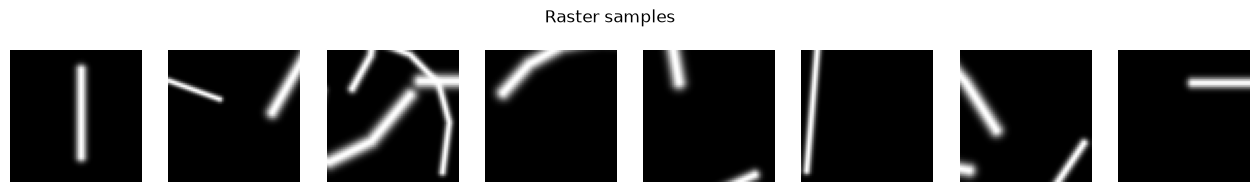

In [7]:
def show_rasters(images, n=8, title="Raster samples"):
    n = min(n, len(images))
    plt.figure(figsize=(n * 2, 2.2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_rasters(train_images, n=8)

## 6. Sobel edge channel

The model input has two channels: the raster itself and a Sobel edge magnitude channel.

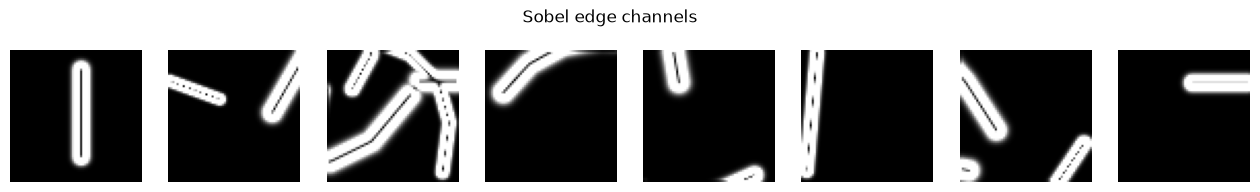

In [8]:
def sobel_edges(x):
    if x.ndim == 3:
        x = x.unsqueeze(1)

    device = x.device
    dtype = x.dtype
    kx = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], device=device, dtype=dtype).view(1, 1, 3, 3)
    ky = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], device=device, dtype=dtype).view(1, 1, 3, 3)
    gx = F.conv2d(x, kx, padding=1)
    gy = F.conv2d(x, ky, padding=1)
    return torch.sqrt(gx ** 2 + gy ** 2 + 1e-8).clamp(0.0, 1.0)


def make_model_input(raster_batch):
    return torch.cat([raster_batch, sobel_edges(raster_batch)], dim=1)

with torch.no_grad():
    sample_edges = sobel_edges(train_images[:8])
show_rasters(sample_edges, n=8, title="Sobel edge channels")

## 7. CNN vector predictor

In [9]:
class VectorPredictor(nn.Module):
    def __init__(self, max_pred_items=MAX_PRED_ITEMS):
        super().__init__()
        self.max_pred_items = max_pred_items
        self.params_per_item = 10

        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(192 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(512, max_pred_items * self.params_per_item),
        )
        self._init_biases()

    def _init_biases(self):
        final = self.head[-1]
        with torch.no_grad():
            final.bias.zero_()
            for slot in range(self.max_pred_items):
                base = slot * self.params_per_item
                final.bias[base + 0] = -2.0  # low initial existence confidence
                final.bias[base + 1] = 0.2   # slight line bias
                final.bias[base + 2] = 0.0
                final.bias[base + 9] = -0.5

    def forward(self, x):
        raw = self.head(self.encoder(x))
        return raw.view(-1, self.max_pred_items, self.params_per_item)


def decode_model_output(raw, img_size=IMG_SIZE):
    exists = torch.sigmoid(raw[:, :, 0])
    type_probs = F.softmax(raw[:, :, 1:3], dim=-1)
    coords = torch.sigmoid(raw[:, :, 3:9]) * (1.0 + 2.0 * OVERHANG) - OVERHANG
    widths_px = 0.7 + 2.5 * torch.sigmoid(raw[:, :, 9])
    widths = widths_px / img_size
    return exists, type_probs, coords, widths


def render_model_output(raw, img_size=IMG_SIZE):
    exists, type_probs, coords, widths = decode_model_output(raw, img_size=img_size)
    raster = render_decoded_primitives(exists, type_probs, coords, widths, img_size=img_size)
    return raster, (exists, type_probs, coords, widths)

model = VectorPredictor().to(DEVICE)
print(model)

VectorPredictor(
  (encoder): Sequential(
    (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchN

## 8. Raster similarity loss

In [10]:
def per_sample_reconstruction_loss(pred, target):
    eps = 1e-6
    pred_safe = pred.clamp(1e-4, 1.0 - 1e-4)
    bce = F.binary_cross_entropy(pred_safe, target, reduction="none").mean(dim=(1, 2))

    intersection = (pred * target).sum(dim=(1, 2))
    pred_sum = pred.sum(dim=(1, 2))
    target_sum = target.sum(dim=(1, 2))
    union = pred_sum + target_sum - intersection

    soft_iou = (intersection + eps) / (union + eps)
    dice_loss = 1.0 - ((2.0 * intersection + eps) / (pred_sum + target_sum + eps))

    edge_loss = F.l1_loss(
        sobel_edges(pred.unsqueeze(1)),
        sobel_edges(target.unsqueeze(1)),
        reduction="none",
    ).mean(dim=(1, 2, 3))

    per_sample = bce + dice_loss + EDGE_LOSS_WEIGHT * edge_loss
    return per_sample, {"soft_iou": soft_iou.detach(), "bce": bce.detach(), "dice_loss": dice_loss.detach(), "edge_loss": edge_loss.detach()}


def training_loss(pred, target, exists):
    per_sample, metrics = per_sample_reconstruction_loss(pred, target)

    if USE_MATCH_WEIGHTING:
        sample_weight = 1.0 + MATCH_WEIGHT_STRENGTH * metrics["soft_iou"]
        recon = (per_sample * sample_weight).mean()
    else:
        recon = per_sample.mean()

    sparsity = exists.mean()
    total = recon + SPARSITY_WEIGHT * sparsity
    return total, {"loss": total.detach(), "recon": recon.detach(), "sparsity": sparsity.detach(), **metrics}


def raster_metrics(pred, target, threshold=0.35):
    pred_bin = pred >= threshold
    target_bin = target >= threshold
    tp = (pred_bin & target_bin).sum(dim=(1, 2)).float()
    fp = (pred_bin & ~target_bin).sum(dim=(1, 2)).float()
    fn = (~pred_bin & target_bin).sum(dim=(1, 2)).float()
    union = (pred_bin | target_bin).sum(dim=(1, 2)).float()
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    iou = tp / (union + 1e-6)
    mse = ((pred - target) ** 2).mean(dim=(1, 2))
    return {"precision": precision.mean().item(), "recall": recall.mean().item(), "f1": f1.mean().item(), "iou": iou.mean().item(), "mse": mse.mean().item()}

## 9. Train

In [11]:
train_loader = DataLoader(
    TensorDataset(train_images),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    TensorDataset(val_images),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=(DEVICE.type == "cuda"),
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS, 1))

history = {"train_loss": [], "train_iou": [], "val_loss": [], "val_iou": [], "val_f1": []}

# Hard metrics require thresholding and CPU transfer. They are useful, but slow if done every batch.
METRIC_EVERY_N_BATCHES = 4
USE_AMP = DEVICE.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)


def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_iou = 0.0
    hard_metrics = []
    n_batches = 0

    mode = "train" if train else "val"
    pbar = tqdm(loader, desc=mode, leave=True, dynamic_ncols=True)

    for batch_idx, (raster_batch,) in enumerate(pbar, start=1):
        raster_batch = raster_batch.to(DEVICE, non_blocking=True)
        target = raster_batch[:, 0]
        model_input = make_model_input(raster_batch)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
                raw = model(model_input)
                pred, decoded = render_model_output(raw)
                exists = decoded[0]
                loss, loss_metrics = training_loss(pred, target, exists)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.inference_mode():
                raw = model(model_input)
                pred, decoded = render_model_output(raw)
                exists = decoded[0]
                loss, loss_metrics = training_loss(pred, target, exists)

        batch_loss = float(loss_metrics["loss"].detach().cpu())
        batch_iou = float(loss_metrics["soft_iou"].mean().detach().cpu())
        total_loss += batch_loss
        total_iou += batch_iou

        # Only calculate the slower hard metrics occasionally during training.
        if (not train) or (batch_idx % METRIC_EVERY_N_BATCHES == 0) or (batch_idx == len(loader)):
            hard_metrics.append(raster_metrics(pred.detach().cpu(), target.detach().cpu()))

        n_batches += 1
        pbar.set_postfix(loss=f"{batch_loss:.4f}", soft_iou=f"{batch_iou:.4f}")

    if hard_metrics:
        avg_hard = {key: float(np.mean([m[key] for m in hard_metrics])) for key in hard_metrics[0]}
    else:
        avg_hard = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "iou": 0.0, "mse": 0.0}

    return {"loss": total_loss / n_batches, "soft_iou": total_iou / n_batches, **avg_hard}


for epoch in range(1, EPOCHS + 1):
    train_stats = run_epoch(model, train_loader, train=True)
    val_stats = run_epoch(model, val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(train_stats["loss"])
    history["train_iou"].append(train_stats["soft_iou"])
    history["val_loss"].append(val_stats["loss"])
    history["val_iou"].append(val_stats["soft_iou"])
    history["val_f1"].append(val_stats["f1"])

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_stats['loss']:.4f}, soft IoU {train_stats['soft_iou']:.4f} | "
        f"val loss {val_stats['loss']:.4f}, soft IoU {val_stats['soft_iou']:.4f}, hard F1 {val_stats['f1']:.4f}"
    )


val: 100%|██████████| 8/8 [00:00<00:00, 11.01it/s, loss=1.4321, soft_iou=0.0325]


Epoch 01/3 | train loss 1.3553, soft IoU 0.0347 | val loss 1.3693, soft IoU 0.0347, hard F1 0.0000


val: 100%|██████████| 8/8 [00:00<00:00, 11.79it/s, loss=1.3215, soft_iou=0.0786]


Epoch 02/3 | train loss 1.2600, soft IoU 0.0619 | val loss 1.2648, soft IoU 0.0796, hard F1 0.0991


val: 100%|██████████| 8/8 [00:00<00:00,  9.24it/s, loss=1.3060, soft_iou=0.1023]

Epoch 03/3 | train loss 1.2425, soft IoU 0.0728 | val loss 1.2603, soft IoU 0.0992, hard F1 0.1980


## 10. Training curves

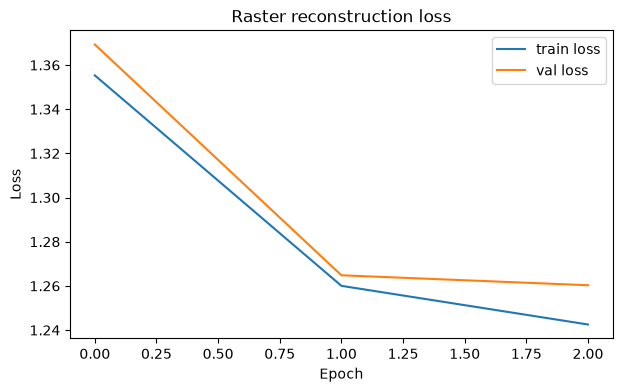

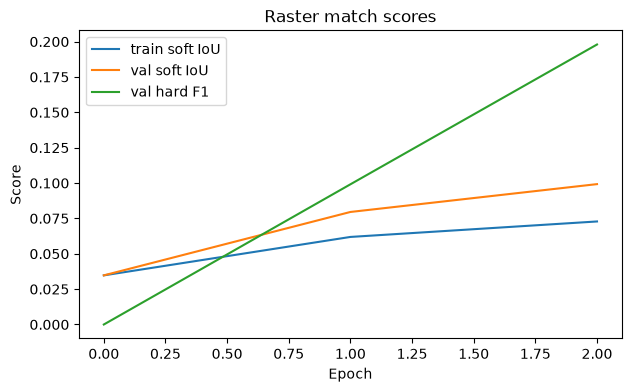

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Raster reconstruction loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["train_iou"], label="train soft IoU")
plt.plot(history["val_iou"], label="val soft IoU")
plt.plot(history["val_f1"], label="val hard F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Raster match scores")
plt.legend()
plt.show()

## 11. Extract predicted vectors and export SVG

In [13]:
def extract_vector_items(raw, confidence_threshold=0.20, max_items=None, img_size=IMG_SIZE):
    if raw.ndim == 2:
        raw = raw.unsqueeze(0)

    exists, type_probs, coords, widths = decode_model_output(raw.to(DEVICE), img_size=img_size)
    exists = exists[0].detach().cpu().numpy()
    type_probs = type_probs[0].detach().cpu().numpy()
    coords = coords[0].detach().cpu().numpy()
    widths = widths[0].detach().cpu().numpy()

    order = np.argsort(-exists)
    items = []
    for idx in order:
        confidence = float(exists[idx])
        if confidence < confidence_threshold:
            continue
        primitive_type = "curve" if type_probs[idx, 1] >= type_probs[idx, 0] else "line"
        p0 = coords[idx, 0:2] * (img_size - 1)
        p1 = coords[idx, 2:4] * (img_size - 1)
        p2 = coords[idx, 4:6] * (img_size - 1)
        items.append({
            "type": primitive_type,
            "confidence": confidence,
            "line_probability": float(type_probs[idx, 0]),
            "curve_probability": float(type_probs[idx, 1]),
            "p0": [float(p0[0]), float(p0[1])],
            "p1": [float(p1[0]), float(p1[1])],
            "p2": [float(p2[0]), float(p2[1])],
            "width_px": float(widths[idx] * img_size),
        })
        if max_items is not None and len(items) >= max_items:
            break
    return items


def vectorise_image(model, raster_image, confidence_threshold=0.20):
    model.eval()
    if raster_image.ndim == 2:
        raster_image = raster_image.unsqueeze(0)
    if raster_image.ndim == 3:
        raster_image = raster_image.unsqueeze(0)

    raster_image = raster_image.to(DEVICE).float()
    with torch.no_grad():
        raw = model(make_model_input(raster_image))
        pred_raster, _ = render_model_output(raw)
    return extract_vector_items(raw, confidence_threshold), pred_raster[0].cpu(), raw.cpu()


def save_svg(vector_items, path, img_size=IMG_SIZE):
    path = Path(path)
    lines = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{img_size}" height="{img_size}" viewBox="0 0 {img_size} {img_size}">',
        '<rect width="100%" height="100%" fill="white"/>',
    ]
    for item in vector_items:
        width = max(0.5, item["width_px"])
        if item["type"] == "line":
            x0, y0 = item["p0"]
            x2, y2 = item["p2"]
            lines.append(f'<line x1="{x0:.3f}" y1="{y0:.3f}" x2="{x2:.3f}" y2="{y2:.3f}" stroke="black" stroke-width="{width:.3f}" stroke-linecap="round"/>')
        else:
            x0, y0 = item["p0"]
            x1, y1 = item["p1"]
            x2, y2 = item["p2"]
            lines.append(f'<path d="M {x0:.3f},{y0:.3f} Q {x1:.3f},{y1:.3f} {x2:.3f},{y2:.3f}" fill="none" stroke="black" stroke-width="{width:.3f}" stroke-linecap="round"/>')
    lines.append("</svg>")
    path.write_text("\n".join(lines), encoding="utf-8")
    return path

## 12. Visualise model predictions

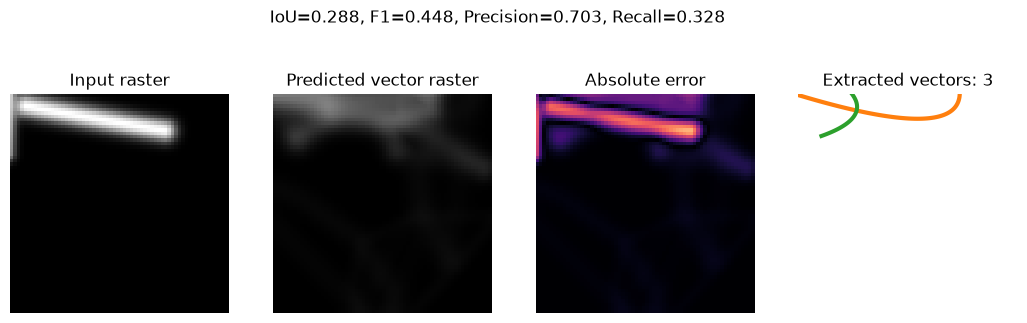

[
  {
    "type": "line",
    "confidence": 0.5471110343933105,
    "line_probability": 0.506918728351593,
    "curve_probability": 0.493081271648407,
    "p0": [
      -8.214677810668945,
      -5.577200412750244
    ],
    "p1": [
      46.04082107543945,
      14.368180274963379
    ],
    "p2": [
      59.68791961669922,
      -21.23517608642578
    ],
    "width_px": 3.0671944618225098
  },
  {
    "type": "curve",
    "confidence": 0.4075775444507599,
    "line_probability": 0.2930864989757538,
    "curve_probability": 0.7069135308265686,
    "p0": [
      45.32447814941406,
      -5.41593074798584
    ],
    "p1": [
      54.34608840942383,
      18.83685302734375
    ],
    "p2": [
      -12.927488327026367,
      -3.795076847076416
    ],
    "width_px": 3.0236690044403076
  },
  {
    "type": "curve",
    "confidence": 0.22295443713665009,
    "line_probability": 0.31328362226486206,
    "curve_probability": 0.6867163181304932,
    "p0": [
      6.607759475708008,
      12.08

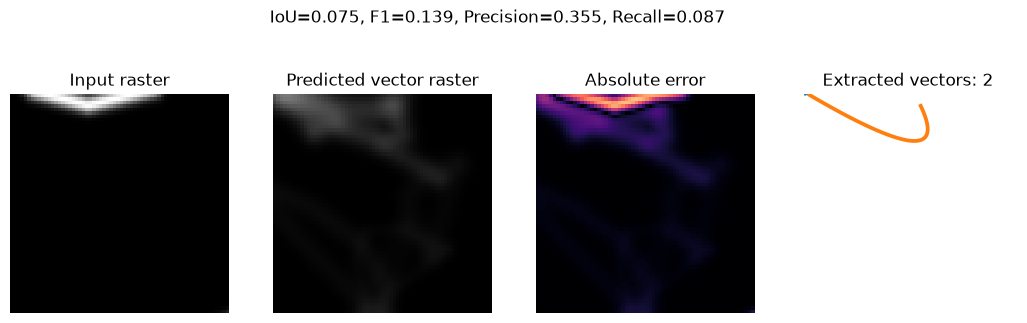

[
  {
    "type": "line",
    "confidence": 0.2500154376029968,
    "line_probability": 0.5797325968742371,
    "curve_probability": 0.4202674329280853,
    "p0": [
      2.0941362380981445,
      -0.1690749228000641
    ],
    "p1": [
      39.30409622192383,
      16.901718139648438
    ],
    "p2": [
      38.9154052734375,
      -14.137179374694824
    ],
    "width_px": 2.784846305847168
  },
  {
    "type": "curve",
    "confidence": 0.22392326593399048,
    "line_probability": 0.37054821848869324,
    "curve_probability": 0.6294517517089844,
    "p0": [
      35.152099609375,
      3.410881996154785
    ],
    "p1": [
      45.44118118286133,
      25.067922592163086
    ],
    "p2": [
      3.1979458332061768,
      0.2970634996891022
    ],
    "width_px": 2.707301378250122
  }
]


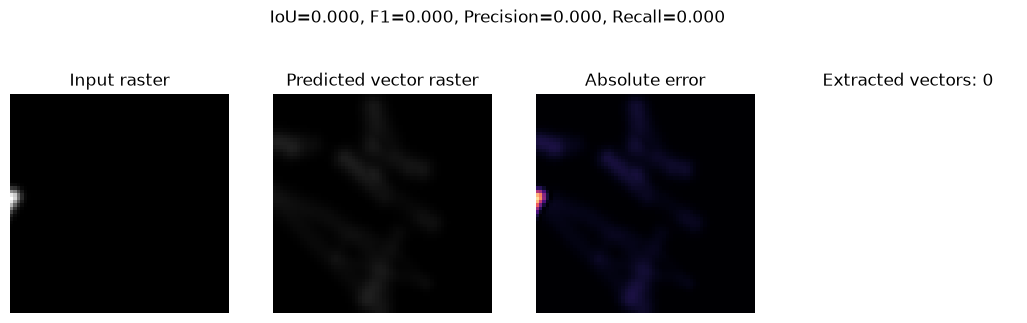

[]


In [14]:
def plot_vector_overlay(ax, vector_items, img_size=IMG_SIZE):
    for item in vector_items:
        width = max(0.7, item["width_px"])
        if item["type"] == "line":
            x0, y0 = item["p0"]
            x2, y2 = item["p2"]
            ax.plot([x0, x2], [y0, y2], linewidth=width)
        else:
            p0 = np.array(item["p0"])
            p1 = np.array(item["p1"])
            p2 = np.array(item["p2"])
            ts = np.linspace(0, 1, 80)[:, None]
            pts = ((1 - ts) ** 2) * p0 + 2 * (1 - ts) * ts * p1 + (ts ** 2) * p2
            ax.plot(pts[:, 0], pts[:, 1], linewidth=width)
    ax.set_xlim(0, img_size - 1)
    ax.set_ylim(img_size - 1, 0)
    ax.set_aspect("equal")
    ax.axis("off")


def show_prediction(index=0, confidence_threshold=0.20, save_svg_file=False):
    target = val_images[index]
    vector_items, pred_raster, raw = vectorise_image(model, target, confidence_threshold=confidence_threshold)

    target_2d = target[0]
    error = torch.abs(pred_raster - target_2d)
    metrics = raster_metrics(pred_raster.unsqueeze(0), target_2d.unsqueeze(0))

    plt.figure(figsize=(13, 4))
    ax = plt.subplot(1, 4, 1)
    ax.imshow(target_2d.numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title("Input raster")
    ax.axis("off")

    ax = plt.subplot(1, 4, 2)
    ax.imshow(pred_raster.numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title("Predicted vector raster")
    ax.axis("off")

    ax = plt.subplot(1, 4, 3)
    ax.imshow(error.numpy(), cmap="magma", vmin=0, vmax=1)
    ax.set_title("Absolute error")
    ax.axis("off")

    ax = plt.subplot(1, 4, 4)
    ax.imshow(np.ones((IMG_SIZE, IMG_SIZE)), cmap="gray", vmin=0, vmax=1)
    plot_vector_overlay(ax, vector_items)
    ax.set_title(f"Extracted vectors: {len(vector_items)}")

    plt.suptitle(f"IoU={metrics['iou']:.3f}, F1={metrics['f1']:.3f}, Precision={metrics['precision']:.3f}, Recall={metrics['recall']:.3f}")
    plt.show()

    print(json.dumps(vector_items[:8], indent=2))

    if save_svg_file:
        out_path = save_svg(vector_items, f"prediction_{index}.svg")
        print("Saved:", out_path.resolve())

show_prediction(index=0, confidence_threshold=0.20, save_svg_file=True)
show_prediction(index=1, confidence_threshold=0.20, save_svg_file=False)
show_prediction(index=2, confidence_threshold=0.20, save_svg_file=False)

## 13. Save and reload the model

In [15]:
checkpoint_path = Path("vectoriser_lines_curves_64px.pt")

torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "img_size": IMG_SIZE,
        "max_true_items": MAX_TRUE_ITEMS,
        "max_pred_items": MAX_PRED_ITEMS,
        "overhang": OVERHANG,
        "curve_segments": CURVE_SEGMENTS,
    },
    "history": history,
}, checkpoint_path)

print("Saved model checkpoint to:", checkpoint_path.resolve())

# To reload later:
# checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
# model = VectorPredictor(max_pred_items=checkpoint["config"]["max_pred_items"]).to(DEVICE)
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()

Saved model checkpoint to: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\vectoriser_lines_curves_64px.pt


## 14. Scaling this up

For better results, increase these settings:

- `N_TRAIN = 10000` or more;
- `EPOCHS = 50` or more;
- `MAX_PRED_ITEMS = 24` or `32` if you want the model to use many vectors;
- lower `SPARSITY_WEIGHT` if it is not using enough vectors;
- raise `CURVE_SEGMENTS` for smoother differentiable curves.

A good two-stage approach is to train with `MAX_PRED_ITEMS = 8` first, then train a larger model with `MAX_PRED_ITEMS = 24` or `32`.